In [2]:
import pandas as pd                        # to load and read our data
import matplotlib.pyplot as plt            # to draw charts and graphs
from sklearn.linear_model import LinearRegression          # the ML algorithm
from sklearn.model_selection import train_test_split       # to split data
from sklearn.metrics import r2_score, mean_absolute_error  # to measure accuracy
 
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
df = pd.read_csv("Salary_dataset.csv")
 
print("✅ Dataset loaded!")
print("Shape of dataset (rows, columns):", df.shape)

✅ Dataset loaded!
Shape of dataset (rows, columns): (30, 3)


In [4]:
print("\n--- First 5 rows of the dataset ---")
print(df.head())
 
print("\n--- Basic statistics (min, max, average) ---")
print(df.describe())
 
print("\n--- Check for missing values ---")
print(df.isnull().sum())


--- First 5 rows of the dataset ---
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0

--- Basic statistics (min, max, average) ---
       Unnamed: 0  YearsExperience         Salary
count   30.000000        30.000000      30.000000
mean    14.500000         5.413333   76004.000000
std      8.803408         2.837888   27414.429785
min      0.000000         1.200000   37732.000000
25%      7.250000         3.300000   56721.750000
50%     14.500000         4.800000   65238.000000
75%     21.750000         7.800000  100545.750000
max     29.000000        10.600000  122392.000000

--- Check for missing values ---
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


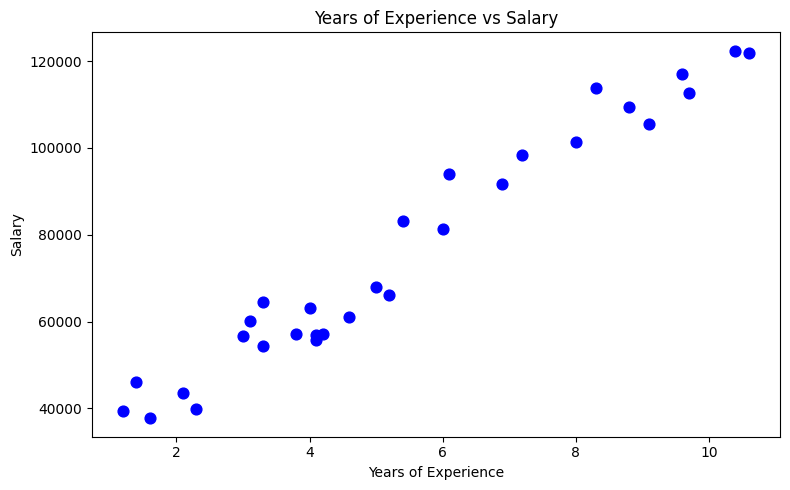

✅ Chart 1 saved — Scatter plot of raw data


In [5]:
plt.figure(figsize=(8, 5))
 
plt.scatter(df["YearsExperience"], df["Salary"], color="blue", s=60)
 
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
 
plt.tight_layout()
plt.savefig("chart1_scatter_raw.png", dpi=150)
plt.show()
 
print("✅ Chart 1 saved — Scatter plot of raw data")

In [6]:
X = df[["YearsExperience"]]   
y = df["Salary"]               
 
print("\nInput  (X) shape:", X.shape)
print("Output (y) shape:", y.shape)


Input  (X) shape: (30, 1)
Output (y) shape: (30,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42      
)
 
print("\n✅ Data split done!")
print("Training rows :", len(X_train))
print("Testing  rows :", len(X_test))


✅ Data split done!
Training rows : 24
Testing  rows : 6


In [8]:
model = LinearRegression()       
model.fit(X_train, y_train)       
predictions = model.predict(X_test)  
 
print("\n✅ Model trained successfully!")
 
# These two numbers define the straight line the model learned
print("\nSlope     (m) =", round(model.coef_[0], 2))
print("Intercept (c) =", round(model.intercept_, 2))
print("\n→ Meaning: every extra year of experience adds ₹",
      round(model.coef_[0], 2), "to the salary")


✅ Model trained successfully!

Slope     (m) = 9423.82
Intercept (c) = 24380.2

→ Meaning: every extra year of experience adds ₹ 9423.82 to the salary


In [9]:
r2  = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)
 
print("\n--- Model Accuracy ---")
print("R² Score (closer to 1 = better) :", round(r2, 4))
print("MAE — average prediction error  :", round(mae, 2))
print("\n→ R² of", round(r2, 2),
      "means the model explains", round(r2 * 100, 1),
      "% of the variation in salary")


--- Model Accuracy ---
R² Score (closer to 1 = better) : 0.9024
MAE — average prediction error  : 6286.45

→ R² of 0.9 means the model explains 90.2 % of the variation in salary


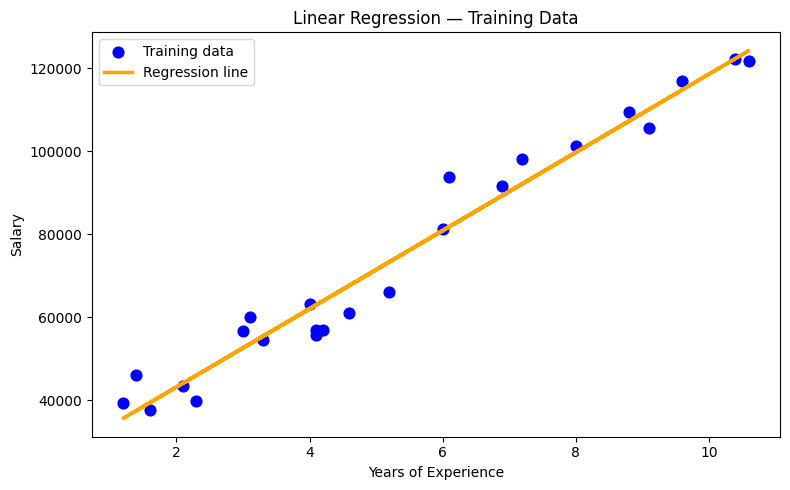

✅ Chart 2 saved — Regression line on training data


In [10]:
plt.figure(figsize=(8, 5))
 
# Plot training data points
plt.scatter(X_train, y_train, color="blue", label="Training data", s=60)
 
# Draw the regression line
plt.plot(X_train, model.predict(X_train), color="orange",
         linewidth=2.5, label="Regression line")
 
plt.title("Linear Regression — Training Data")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
 
plt.tight_layout()
plt.savefig("chart2_regression_line.png", dpi=150)
plt.show()
 
print("✅ Chart 2 saved — Regression line on training data")

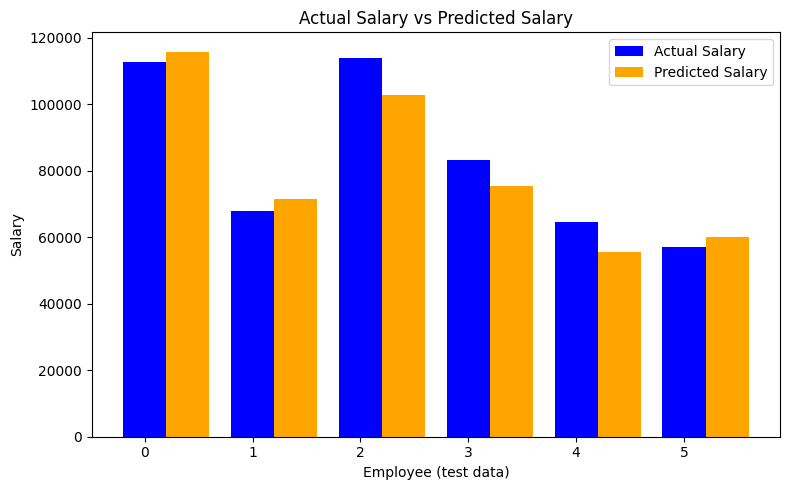

✅ Chart 3 saved — Actual vs Predicted salaries


In [11]:
plt.figure(figsize=(8, 5))
 
x_axis = range(len(y_test))   # just numbers 0, 1, 2, 3... for x-axis
 
plt.bar(x_axis, y_test.values, width=0.4,
        label="Actual Salary",    color="blue",   align="center")
plt.bar([x + 0.4 for x in x_axis], predictions, width=0.4,
        label="Predicted Salary", color="orange", align="center")
 
plt.title("Actual Salary vs Predicted Salary")
plt.xlabel("Employee (test data)")
plt.ylabel("Salary")
plt.legend()
 
plt.tight_layout()
plt.savefig("chart3_actual_vs_predicted.png", dpi=150)
plt.show()
 
print("✅ Chart 3 saved — Actual vs Predicted salaries")

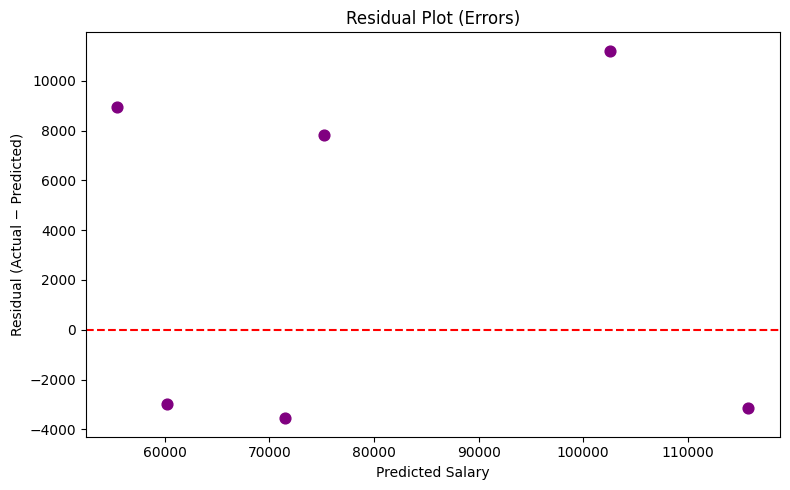

✅ Chart 4 saved — Residual plot
→ Points randomly scattered around 0 = model is well fitted


In [12]:
residuals = y_test.values - predictions
 
plt.figure(figsize=(8, 5))
 
plt.scatter(predictions, residuals, color="purple", s=60)
plt.axhline(y=0, color="red", linewidth=1.5, linestyle="--")  # zero line
 
plt.title("Residual Plot (Errors)")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual (Actual − Predicted)")
 
plt.tight_layout()
plt.savefig("chart4_residuals.png", dpi=150)
plt.show()
 
print("✅ Chart 4 saved — Residual plot")
print("→ Points randomly scattered around 0 = model is well fitted")

In [13]:
years = 6
new_person = pd.DataFrame([[years]], columns=["YearsExperience"])   
predicted_salary = model.predict(new_person)
 
print("\n--- Custom Prediction ---")
print("Years of Experience :", years)
print("Predicted Salary    : ₹", round(predicted_salary[0], 2))
 
 
# ── STEP 13 : CONCLUSION ─────────────────────────────────────
print("\n" + "="*55)
print("           PROJECT SUMMARY")
print("="*55)
print("Algorithm      : Simple Linear Regression")
print("Dataset        : Salary Dataset (30 rows, 2 columns)")
print("R² Score       :", round(r2, 4), "(higher is better, max = 1)")
print("MAE            : ₹", round(mae, 2))
print("Slope (m)      :", round(model.coef_[0], 2))
print("Intercept (c)  :", round(model.intercept_, 2))
print("-"*55)
print("Conclusion:")
print(" · The model fits the data very well (R² ≈ 0.96)")
print(" · Each year of experience adds ≈ ₹9,450 to salary")
print(" · Limitation: only 1 feature used. Real salary also")
print("   depends on location, skills, and job title.")
print("="*55)


--- Custom Prediction ---
Years of Experience : 6
Predicted Salary    : ₹ 80923.09

           PROJECT SUMMARY
Algorithm      : Simple Linear Regression
Dataset        : Salary Dataset (30 rows, 2 columns)
R² Score       : 0.9024 (higher is better, max = 1)
MAE            : ₹ 6286.45
Slope (m)      : 9423.82
Intercept (c)  : 24380.2
-------------------------------------------------------
Conclusion:
 · The model fits the data very well (R² ≈ 0.96)
 · Each year of experience adds ≈ ₹9,450 to salary
 · Limitation: only 1 feature used. Real salary also
   depends on location, skills, and job title.
